  PASO 1: Cargando dataset...
  → Registros totales cargados: 27,051
  → Columnas totales: 79

  PASO 2: Seleccionando columnas relevantes...
  ✓ Columna 'accommodates' encontrada
  ✓ Columna 'bedrooms' encontrada
  ✓ Columna 'bathrooms' encontrada
  ✓ Columna 'bathrooms_text' encontrada
  ✓ Columna 'price' encontrada

  PASO 3: Limpiando columna de precios...
  → Ejemplo de conversión: '$3,673.00' → 3673.0
  → Precios válidos: 23,567
  → Precios nulos:   3,484

  PASO 4: Limpiando columna de baños...
  → Baños válidos: 27,030
  → Valores únicos de baños: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.5), np.float64(5.0), np.float64(5.5), np.float64(6.0)]

  PASO 5: Preparando dataset limpio...
  → Registros antes de limpiar:  27,051
  → Registros después de limpiar: 23,457
  → Eliminados por datos faltantes: 3,594
  → Registros después de quitar outliers: 23,222
  → Rango de precios: $61 - $9,943 MXN

  Estadísticas 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)


  Entrenando por 200 epochs...
Epoch 1/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1928086.6250 - mae: 907.6449 - val_loss: 1037626.8125 - val_mae: 606.0527
Epoch 2/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1027773.9375 - mae: 608.3341 - val_loss: 983945.1250 - val_mae: 609.6902
Epoch 3/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 992876.3750 - mae: 606.2811 - val_loss: 968697.1875 - val_mae: 592.6103
Epoch 4/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 973235.5625 - mae: 604.9036 - val_loss: 956761.8125 - val_mae: 604.5851
Epoch 5/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 962844.1250 - mae: 604.8755 - val_loss: 949759.9375 - val_mae: 601.7761
Epoch 6/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 959919.1250 - mae: 605.5079 - val_loss: 946836.8750 - val_mae: 610.2537
Epoch 7/200
494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 953389.5000 - mae: 606.8652 - val_loss: 943235.4375 - val_mae: 604.8930
Epoch 8/200
494/494 ━━━━━━━━━━━━━━

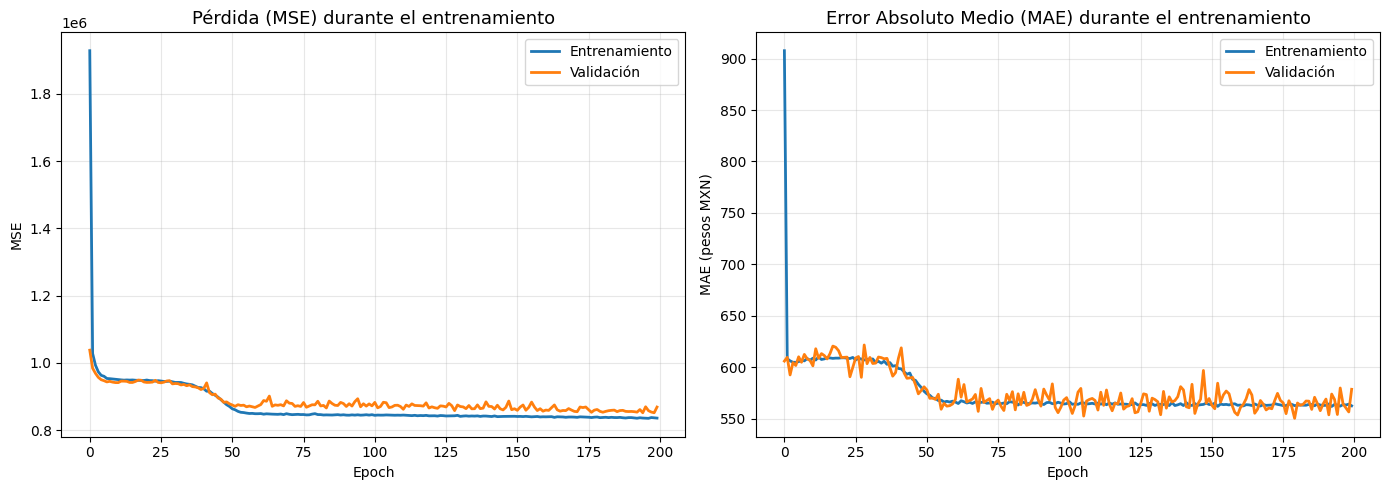

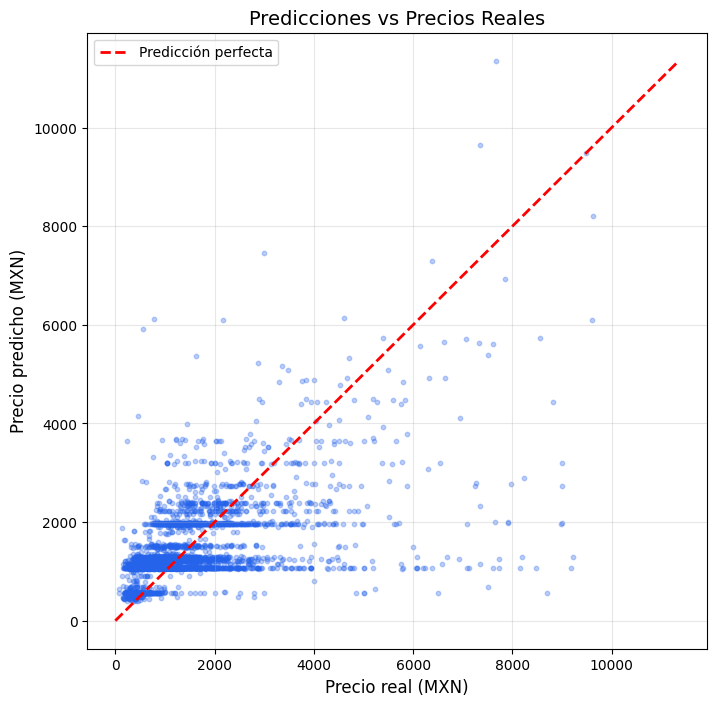

In [ ]:
"""
=============================================================
  RED NEURONAL PARA PREDICCIÓN DE PRECIOS - AIRBNB CDMX
  Dataset: Inside Airbnb (listings.csv.gz detallado)
=============================================================

Instrucciones:
1. Coloca el archivo "listings.csv.gz" en la MISMA carpeta que este script
   (o cambia la variable RUTA_ARCHIVO más abajo).
2. Ejecuta: python entrenar_modelo_airbnb.py
3. El modelo se guardará como "modelo_precios_airbnb.keras"

Requisitos:
  pip install tensorflow pandas numpy scikit-learn matplotlib
"""

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import re
import os

# ─────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────
RUTA_ARCHIVO = "listings.csv.gz"  # <-- Cambia esta ruta si tu archivo está en otro lugar
EPOCHS = 200
LEARNING_RATE = 0.001


# ─────────────────────────────────────────────
# PASO 1: CARGAR DATOS
# ─────────────────────────────────────────────
print("=" * 60)
print("  PASO 1: Cargando dataset...")
print("=" * 60)

df = pd.read_csv(RUTA_ARCHIVO, low_memory=False)
print(f"  → Registros totales cargados: {len(df):,}")
print(f"  → Columnas totales: {len(df.columns)}")


# ─────────────────────────────────────────────
# PASO 2: SELECCIONAR COLUMNAS RELEVANTES
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 2: Seleccionando columnas relevantes...")
print("=" * 60)

# Nos quedamos con las columnas que mapean a tu modelo original:
#   accommodates  →  Capacidad (personas)
#   bedrooms      →  Habitaciones
#   bathrooms_text / bathrooms  →  Baños
#   price         →  Precio por noche (lo que queremos predecir)
columnas_necesarias = ["accommodates", "bedrooms", "bathrooms", "bathrooms_text", "price"]

# Verificar que existen
for col in columnas_necesarias:
    if col in df.columns:
        print(f"  ✓ Columna '{col}' encontrada")
    else:
        print(f"  ✗ Columna '{col}' NO encontrada")


# ─────────────────────────────────────────────
# PASO 3: LIMPIAR EL PRECIO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 3: Limpiando columna de precios...")
print("=" * 60)

# El precio viene como texto: "$1,200.00" → lo convertimos a número: 1200.0
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    texto = str(valor)
    texto = texto.replace("$", "").replace(",", "").strip()
    try:
        return float(texto)
    except ValueError:
        return np.nan

df["price_limpio"] = df["price"].apply(limpiar_precio)

print(f"  → Ejemplo de conversión: '{df['price'].iloc[0]}' → {df['price_limpio'].iloc[0]}")
print(f"  → Precios válidos: {df['price_limpio'].notna().sum():,}")
print(f"  → Precios nulos:   {df['price_limpio'].isna().sum():,}")


# ─────────────────────────────────────────────
# PASO 4: LIMPIAR BAÑOS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 4: Limpiando columna de baños...")
print("=" * 60)

# bathrooms_text viene como: "2 baths", "1 shared bath", "1.5 baths", "Half-bath"
# Extraemos solo el número
def limpiar_banos(row):
    # Primero intentar con la columna numérica 'bathrooms'
    if pd.notna(row.get("bathrooms")):
        try:
            return float(row["bathrooms"])
        except (ValueError, TypeError):
            pass
    # Si no, parsear 'bathrooms_text'
    texto = str(row.get("bathrooms_text", ""))
    if texto == "nan" or texto == "":
        return np.nan
    # Caso especial: "Half-bath" = 0.5
    if "half" in texto.lower():
        return 0.5
    # Extraer el primer número del texto
    numeros = re.findall(r"[\d.]+", texto)
    if numeros:
        return float(numeros[0])
    return np.nan

df["bathrooms_limpio"] = df.apply(limpiar_banos, axis=1)

print(f"  → Baños válidos: {df['bathrooms_limpio'].notna().sum():,}")
print(f"  → Valores únicos de baños: {sorted(df['bathrooms_limpio'].dropna().unique()[:10])}")


# ─────────────────────────────────────────────
# PASO 5: PREPARAR DATASET LIMPIO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 5: Preparando dataset limpio...")
print("=" * 60)

df_limpio = df[["accommodates", "bedrooms", "bathrooms_limpio", "price_limpio"]].copy()
df_limpio.columns = ["capacidad", "habitaciones", "banos", "precio"]

# Convertir a numérico
df_limpio["capacidad"] = pd.to_numeric(df_limpio["capacidad"], errors="coerce")
df_limpio["habitaciones"] = pd.to_numeric(df_limpio["habitaciones"], errors="coerce")

# Eliminar filas con valores nulos
antes = len(df_limpio)
df_limpio = df_limpio.dropna()
despues = len(df_limpio)
print(f"  → Registros antes de limpiar:  {antes:,}")
print(f"  → Registros después de limpiar: {despues:,}")
print(f"  → Eliminados por datos faltantes: {antes - despues:,}")

# Eliminar precios extremos (outliers)
# Quitamos precios <= 0 y los que estén por arriba del percentil 99
precio_min = 1
precio_max = df_limpio["precio"].quantile(0.99)
df_limpio = df_limpio[
    (df_limpio["precio"] > precio_min) & (df_limpio["precio"] <= precio_max)
]
print(f"  → Registros después de quitar outliers: {len(df_limpio):,}")
print(f"  → Rango de precios: ${df_limpio['precio'].min():,.0f} - ${df_limpio['precio'].max():,.0f} MXN")

# Resumen estadístico
print("\n  Estadísticas del dataset limpio:")
print(df_limpio.describe().round(2).to_string())


# ─────────────────────────────────────────────
# PASO 6: SEPARAR DATOS (ENTRENAMIENTO / PRUEBA)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 6: Separando datos de entrenamiento y prueba...")
print("=" * 60)

# Características (X) y objetivo (y)
X = df_limpio[["capacidad", "habitaciones", "banos"]].values
y = df_limpio["precio"].values

# 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"  → Datos de entrenamiento: {len(X_train):,}")
print(f"  → Datos de prueba:        {len(X_test):,}")

# Normalizar las características (MUY importante para redes neuronales)
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

print(f"  → Datos normalizados ✓")
print(f"    Media entrenamiento: {X_train_norm.mean(axis=0).round(4)}")
print(f"    Std entrenamiento:   {X_train_norm.std(axis=0).round(4)}")


# ─────────────────────────────────────────────
# PASO 7: CONSTRUIR Y ENTRENAR EL MODELO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 7: Construyendo y entrenando la red neuronal...")
print("=" * 60)

modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=[3]),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss="mean_squared_error",
    metrics=["mae"]  # Error absoluto medio (más fácil de interpretar)
)

modelo.summary()

print(f"\n  Entrenando por {EPOCHS} epochs...")
historial = modelo.fit(
    X_train_norm, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)
print("  ¡Entrenamiento completado!")


# ─────────────────────────────────────────────
# PASO 8: EVALUAR EL MODELO
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 8: Evaluando el modelo...")
print("=" * 60)

loss, mae = modelo.evaluate(X_test_norm, y_test, verbose=0)
print(f"  → Error cuadrático medio (MSE):  {loss:,.2f}")
print(f"  → Error absoluto medio (MAE):    ${mae:,.2f} MXN")
print(f"    (En promedio, el modelo se equivoca por ~${mae:,.0f} pesos)")


# ─────────────────────────────────────────────
# PASO 9: HACER PREDICCIONES
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PASO 9: Probando predicciones...")
print("=" * 60)

# Ejemplos de hospedajes para predecir
ejemplos = [
    {"capacidad": 2, "habitaciones": 1, "banos": 1, "descripcion": "Depa para pareja, 1 hab, 1 baño"},
    {"capacidad": 4, "habitaciones": 2, "banos": 1, "descripcion": "Depa familiar, 2 habs, 1 baño"},
    {"capacidad": 6, "habitaciones": 3, "banos": 2, "descripcion": "Casa grande, 3 habs, 2 baños"},
    {"capacidad": 8, "habitaciones": 4, "banos": 3, "descripcion": "Casa enorme, 4 habs, 3 baños"},
    {"capacidad": 1, "habitaciones": 1, "banos": 1, "descripcion": "Cuarto privado, 1 persona"},
    {"capacidad": 3, "habitaciones": 2, "banos": 1, "descripcion": "Tu ejemplo original: 3 pers, 2 hab, 1 baño"},
]

for ej in ejemplos:
    entrada = np.array([[ej["capacidad"], ej["habitaciones"], ej["banos"]]])
    entrada_norm = scaler.transform(entrada)
    precio = modelo.predict(entrada_norm, verbose=0)[0][0]
    print(f"  {ej['descripcion']}")
    print(f"    → Precio sugerido: ${max(precio, 0):,.0f} MXN/noche\n")


# ─────────────────────────────────────────────
# PASO 10: GUARDAR MODELO Y GRÁFICAS
# ─────────────────────────────────────────────
print("=" * 60)
print("  PASO 10: Guardando modelo y generando gráficas...")
print("=" * 60)

# Guardar modelo
modelo.save("modelo_precios_airbnb.keras")
print("  → Modelo guardado como 'modelo_precios_airbnb.keras'")

# Guardar el scaler (necesario para futuras predicciones)
np.savez("scaler_params.npz",
         mean=scaler.mean_,
         scale=scaler.scale_)
print("  → Parámetros del scaler guardados en 'scaler_params.npz'")

# Gráfica del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(historial.history["loss"], label="Entrenamiento", linewidth=2)
axes[0].plot(historial.history["val_loss"], label="Validación", linewidth=2)
axes[0].set_title("Pérdida (MSE) durante el entrenamiento", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(historial.history["mae"], label="Entrenamiento", linewidth=2)
axes[1].plot(historial.history["val_mae"], label="Validación", linewidth=2)
axes[1].set_title("Error Absoluto Medio (MAE) durante el entrenamiento", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (pesos MXN)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("grafica_entrenamiento.png", dpi=150, bbox_inches="tight")
print("  → Gráfica guardada como 'grafica_entrenamiento.png'")

# Gráfica de predicciones vs reales
y_pred = modelo.predict(X_test_norm, verbose=0).flatten()
fig2, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#2563EB")
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Predicción perfecta")
ax.set_xlabel("Precio real (MXN)", fontsize=12)
ax.set_ylabel("Precio predicho (MXN)", fontsize=12)
ax.set_title("Predicciones vs Precios Reales", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("predicciones_vs_reales.png", dpi=150, bbox_inches="tight")
print("  → Gráfica guardada como 'predicciones_vs_reales.png'")

print("\n" + "=" * 60)
print("  ¡LISTO! Todo completado exitosamente.")
print("=" * 60)
print("""
  Archivos generados:
    1. modelo_precios_airbnb.keras    → Tu modelo entrenado
    2. scaler_params.npz              → Parámetros de normalización
    3. grafica_entrenamiento.png      → Curvas de aprendizaje
    4. predicciones_vs_reales.png     → Scatter plot de precisión

  Para usar el modelo después:
    modelo = tf.keras.models.load_model("modelo_precios_airbnb.keras")
    params = np.load("scaler_params.npz")
    scaler = StandardScaler()
    scaler.mean_ = params["mean"]
    scaler.scale_ = params["scale"]

    nuevo = np.array([[capacidad, habitaciones, banos]])
    precio = modelo.predict(scaler.transform(nuevo))
""")

In [ ]:
# Guarda el modelo en el directorio actual
modelo.save('modelo_precios.keras')
print("¡Modelo guardado exitosamente!")

¡Modelo guardado exitosamente!
